In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset/quantity_weekly_decor.csv")

df_melted = df.melt(id_vars=['StockCode'], var_name='Week', value_name='Quantity')

# 2. Tạo dãy ngày bắt đầu từ 2010-12-01 (mỗi tuần một lần)
# Tạo dictionary để map Week_1 -> 2010-12-01, Week_2 -> 2010-12-08...
weeks = [f'Week_{i}' for i in range(1, 54)]
dates = pd.date_range(start='2010-12-01', periods=53, freq='W')
date_map = dict(zip(weeks, dates))

df_melted['Date'] = df_melted['Week'].map(date_map)
ts_data = df_melted.pivot(index='Date', columns='StockCode', values='Quantity')

# print(ts_data.head())

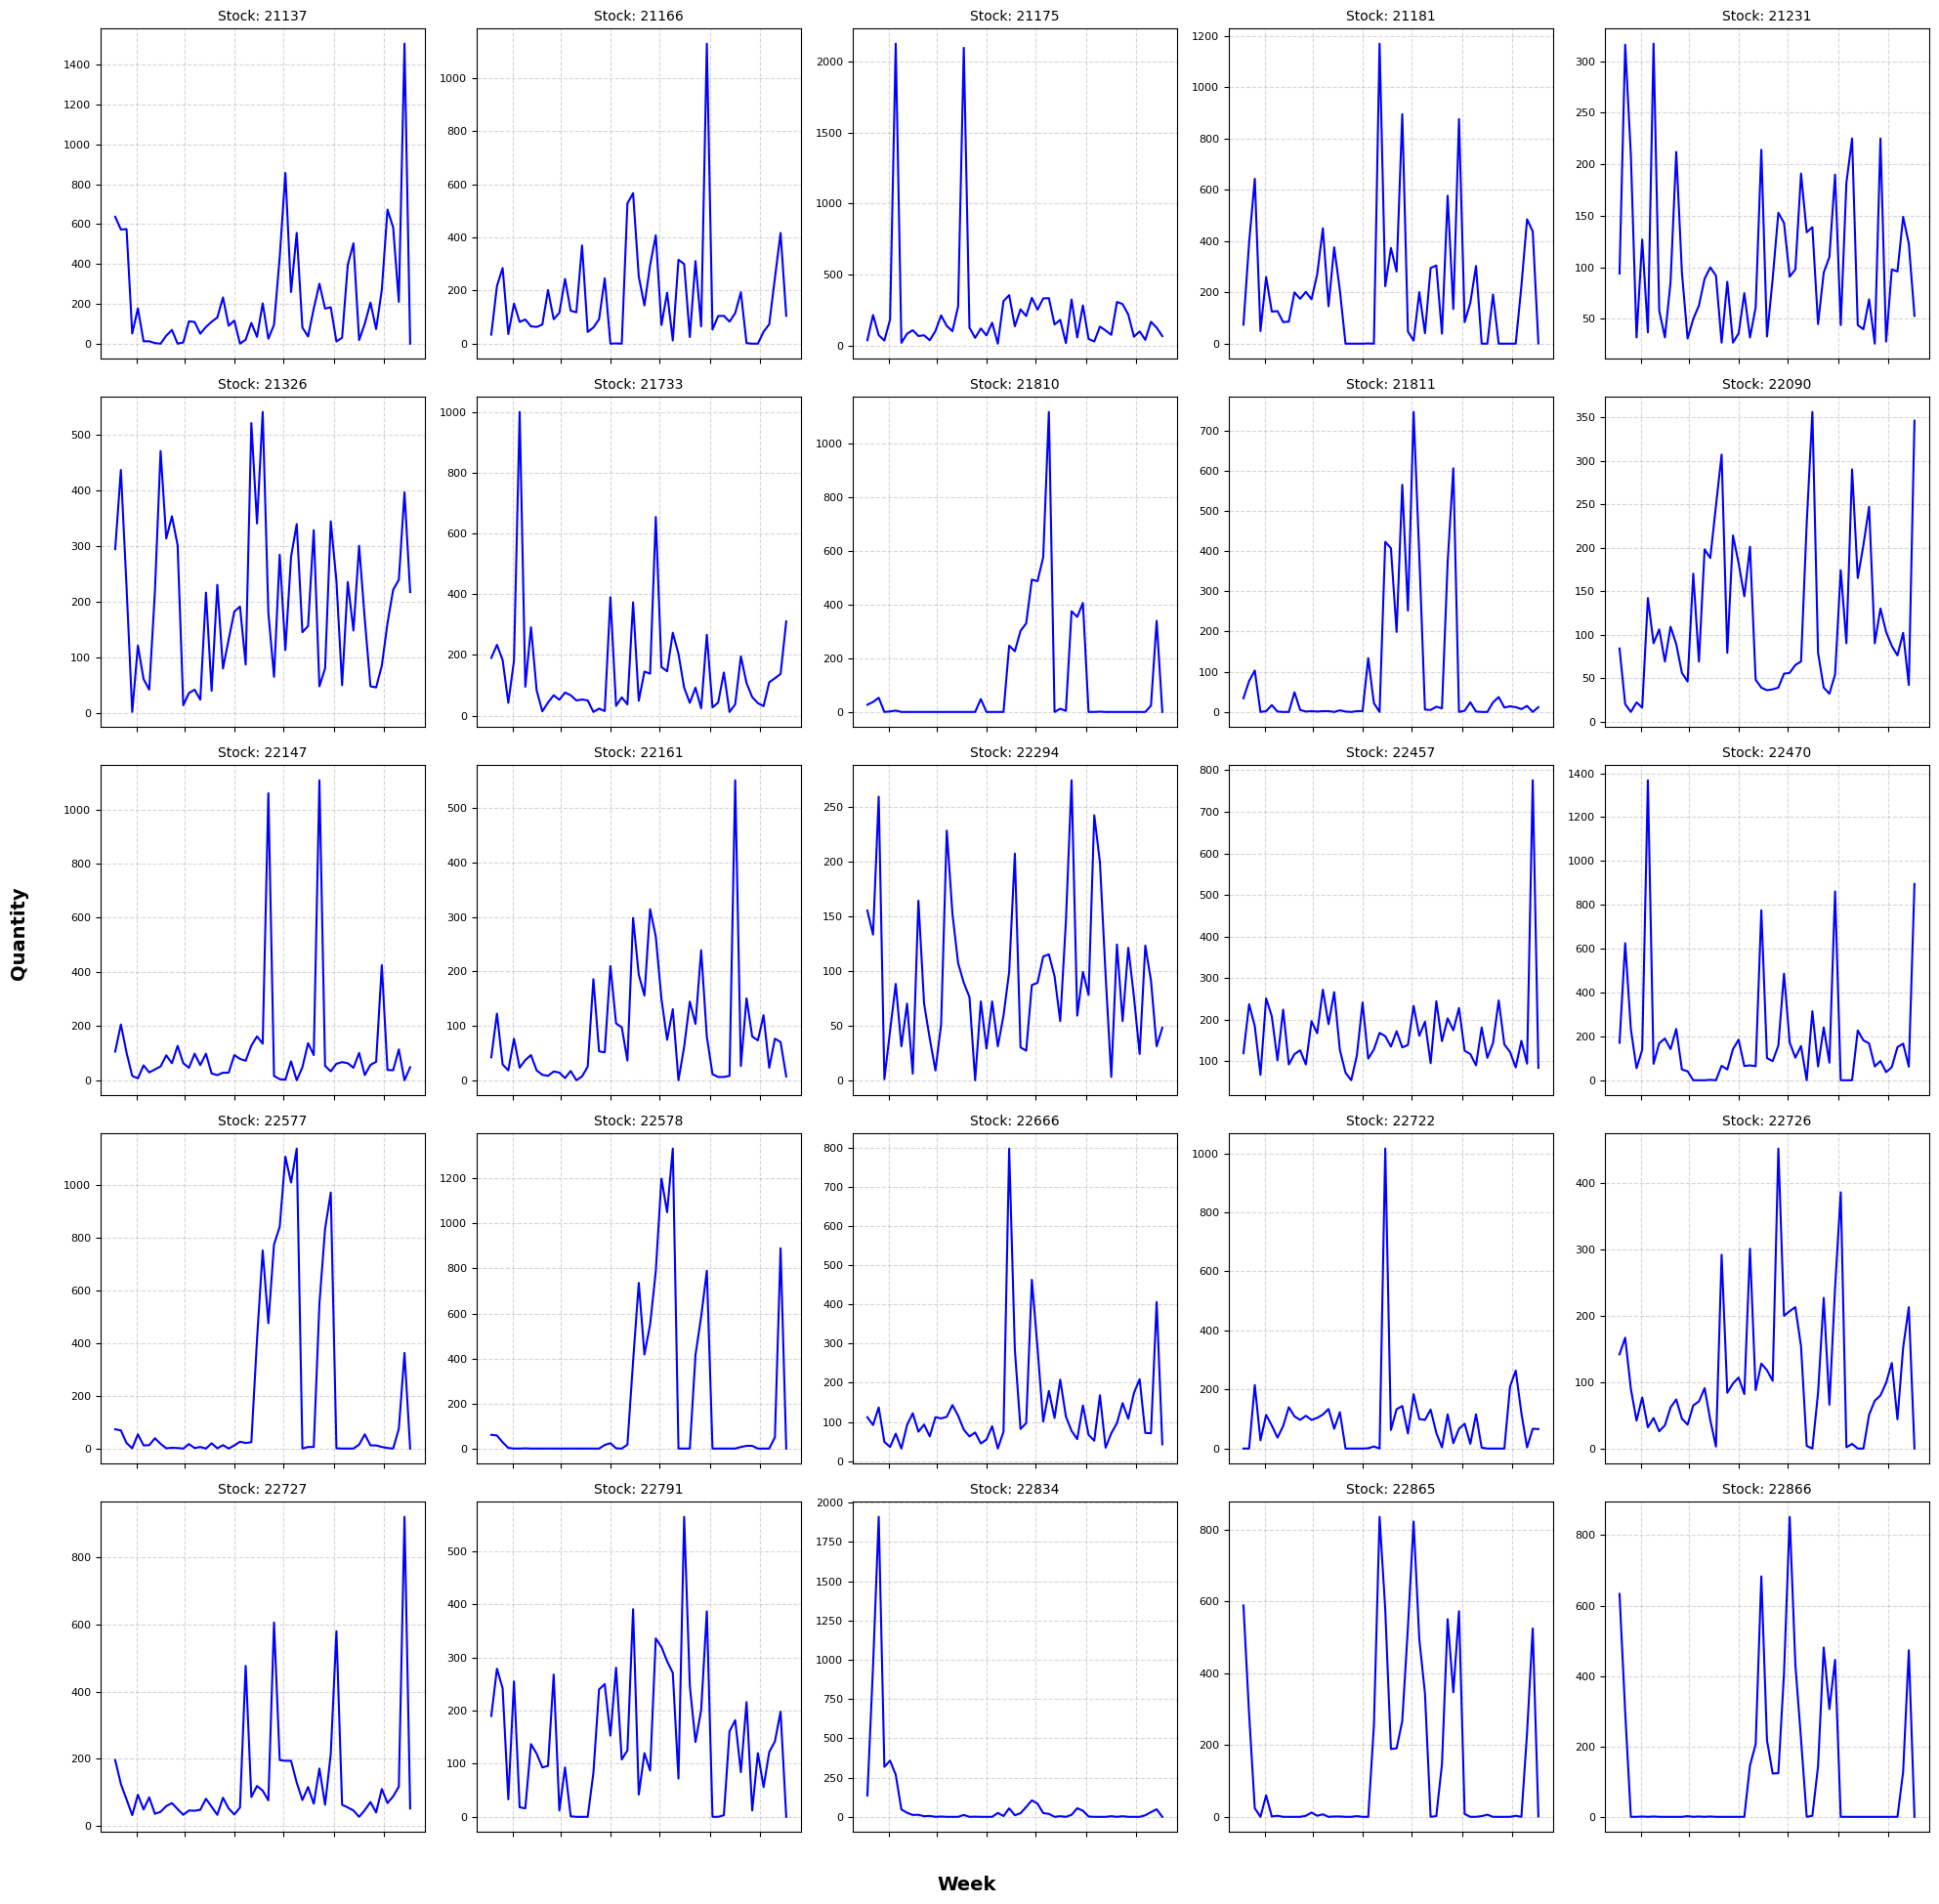

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for i, stock_code in enumerate(ts_data.columns):
    if i < 25:
        axes[i].plot(ts_data.index, ts_data[stock_code], color='blue', linewidth=1.5)
        axes[i].set_title(f"Stock: {stock_code}", fontsize=10)
        axes[i].tick_params(axis='both', which='major', labelsize=8)
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].tick_params(axis='x', which='both', labelbottom=False)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.text(0.5, 0.01, 'Week', ha='center', fontsize=14, fontweight='bold')
fig.text(0.01, 0.5, 'Quantity', va='center', rotation='vertical', fontsize=14, fontweight='bold')

# plt.suptitle("Biểu đồ số lượng sản phẩm trang trí nhà cửa theo tuần (01/12/2010 - 09/12/2011)", fontsize=16)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
plt.show()